In [ ]:
from ggner_3d.cm import get_expected_cis_df, CLR_CONNS, get_eig_data

import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatterSciNotation

from ggner_3d import plotting
plotting.update_rcparams()

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
colors = ['#465775', '#A63446', '#F5B841', '#9DBBAE']
RESOLUTION = 100_000

clr_ = CLR_CONNS(RESOLUTION)

In [ ]:
wtnouv_cis_expected = get_expected_cis_df('WTnoUV', resolution_kb=RESOLUTION//1000, label='chrom')

In [ ]:
eig_vals, eig_vecs = get_eig_data('WTnoUV', resolution=100_000)

In [ ]:
import numpy as np
import pandas as pd


def _add_auc_normalization(
    df,
    group_cols,
    dist_col="dist",
    value_cols=("balanced_avg", "count_avg"),
    upper_dist_bp=None,
    auc_per_limit=False,
):
    if auc_per_limit and upper_dist_bp is None:
        raise ValueError("auc_per_limit=True requires upper_dist_bp.")

    def _norm_group(g):
        g = g.sort_values(dist_col).copy()
        x = g[dist_col].to_numpy(dtype=float)

        for col in value_cols:
            y = g[col].to_numpy(dtype=float)
            m = np.isfinite(x) & np.isfinite(y)
            if auc_per_limit and upper_dist_bp is not None:
                m &= x <= upper_dist_bp

            auc = np.trapz(y[m], x[m]) if m.sum() > 1 else np.nan
            g[f"{col}_auc"] = auc
            g[f"{col}_aucnorm"] = y / auc if np.isfinite(auc) and auc != 0 else np.nan

        return g

    return df.groupby(group_cols, group_keys=False, sort=False).apply(_norm_group)


def cis_expected_by_compartment(
    clr,
    eig_df,
    eig_col="E1",
    weight_col="weight",
    chunksize=5_000_000,
    ignore_diags=0,
    upper_dist_bp=None,
    auc_per_limit=False,
):
    """
    Returns
    -------
    by_chrom, genomewide
    Both include:
      dist (bp), compartment_pair, n_valid, count_sum, balanced_sum, count_avg, balanced_avg,
      count_avg_auc, count_avg_aucnorm, balanced_avg_auc, balanced_avg_aucnorm
    """
    binsize = clr.binsize
    if binsize is None:
        raise ValueError("This function expects a fixed-bin cooler (clr.binsize must be set).")

    bins = clr.bins()[:][["chrom", "start", "end", weight_col]].copy()
    ev = eig_df[["chrom", "start", "end", eig_col]].rename(columns={eig_col: "eig"})
    bins = bins.merge(ev, on=["chrom", "start", "end"], how="left")

    w = bins[weight_col].to_numpy(dtype=float)
    eig = bins["eig"].to_numpy(dtype=float)
    valid_w = np.isfinite(w)

    # +1=A, -1=B, 0=invalid
    comp = np.zeros(len(bins), dtype=np.int8)
    comp[(eig > 0) & valid_w] = 1
    comp[(eig < 0) & valid_w] = -1

    chrom_cat = pd.Categorical(bins["chrom"], categories=clr.chromnames, ordered=True)
    chrom_id = chrom_cat.codes.astype(np.int16)

    # Denominator
    den_rows = []
    for cid, chrom in enumerate(clr.chromnames):
        lo, hi = clr.extent(chrom)
        x = comp[lo:hi]
        A = x == 1
        B = x == -1
        n = hi - lo

        for d in range(ignore_diags, n):
            a0, a1 = A[: n - d], A[d:]
            b0, b1 = B[: n - d], B[d:]

            aa = int(np.count_nonzero(a0 & a1))
            bb = int(np.count_nonzero(b0 & b1))
            ab = int(np.count_nonzero(a0 & b1) + np.count_nonzero(b0 & a1))

            den_rows.append((cid, d, 0, aa))  # AA
            den_rows.append((cid, d, 1, ab))  # AB
            den_rows.append((cid, d, 2, bb))  # BB

    den = pd.DataFrame(den_rows, columns=["chrom_id", "dist_bin", "pair_code", "n_valid"])

    # Numerator from stored pixels
    obs_parts = []
    nnz = clr.info["nnz"]

    for lo in range(0, nnz, chunksize):
        px = clr.pixels()[lo : lo + chunksize][["bin1_id", "bin2_id", "count"]]

        b1 = px["bin1_id"].to_numpy(dtype=np.int64)
        b2 = px["bin2_id"].to_numpy(dtype=np.int64)
        cnt = px["count"].to_numpy(dtype=np.float64)

        same_chrom = chrom_id[b1] == chrom_id[b2]
        upper = b1 <= b2
        dist_bin = b2 - b1

        c1 = comp[b1]
        c2 = comp[b2]
        valid_comp = (c1 != 0) & (c2 != 0)

        keep = same_chrom & upper & (dist_bin >= ignore_diags) & valid_comp
        if not np.any(keep):
            continue

        b1 = b1[keep]
        b2 = b2[keep]
        cnt = cnt[keep]
        dist_bin = dist_bin[keep]
        c1 = c1[keep]
        c2 = c2[keep]

        pair_code = np.ones_like(c1, dtype=np.int8)  # AB
        pair_code[(c1 == 1) & (c2 == 1)] = 0         # AA
        pair_code[(c1 == -1) & (c2 == -1)] = 2       # BB

        bal = cnt * w[b1] * w[b2]

        chunk = pd.DataFrame(
            {
                "chrom_id": chrom_id[b1],
                "dist_bin": dist_bin,
                "pair_code": pair_code,
                "count_sum": cnt,
                "balanced_sum": bal,
            }
        )
        obs_parts.append(
            chunk.groupby(["chrom_id", "dist_bin", "pair_code"], as_index=False).sum()
        )

    if obs_parts:
        obs = (
            pd.concat(obs_parts, ignore_index=True)
            .groupby(["chrom_id", "dist_bin", "pair_code"], as_index=False)
            .sum()
        )
    else:
        obs = pd.DataFrame(
            columns=["chrom_id", "dist_bin", "pair_code", "count_sum", "balanced_sum"]
        )

    out = den.merge(obs, on=["chrom_id", "dist_bin", "pair_code"], how="left")
    out["count_sum"] = out["count_sum"].fillna(0.0)
    out["balanced_sum"] = out["balanced_sum"].fillna(0.0)

    out["count_avg"] = out["count_sum"] / out["n_valid"]
    out["balanced_avg"] = out["balanced_sum"] / out["n_valid"]
    out.loc[out["n_valid"] == 0, ["count_avg", "balanced_avg"]] = np.nan

    pair_map = {0: "AA", 1: "AB", 2: "BB"}
    out["compartment_pair"] = out["pair_code"].map(pair_map)
    out["chrom"] = pd.Categorical.from_codes(out["chrom_id"], categories=clr.chromnames)
    out["dist"] = (out["dist_bin"] * binsize).astype(np.int64)  # bp

    by_chrom = out[
        [
            "chrom",
            "dist",
            "compartment_pair",
            "n_valid",
            "count_sum",
            "balanced_sum",
            "count_avg",
            "balanced_avg",
        ]
    ].sort_values(["chrom", "dist", "compartment_pair"], ignore_index=True)

    genomewide = (
        by_chrom.groupby(["dist", "compartment_pair"], as_index=False)[
            ["n_valid", "count_sum", "balanced_sum"]
        ]
        .sum()
        .sort_values(["dist", "compartment_pair"], ignore_index=True)
    )
    genomewide["count_avg"] = genomewide["count_sum"] / genomewide["n_valid"]
    genomewide["balanced_avg"] = genomewide["balanced_sum"] / genomewide["n_valid"]
    genomewide.loc[genomewide["n_valid"] == 0, ["count_avg", "balanced_avg"]] = np.nan

    # AUC normalization:
    # auc_per_limit=False -> AUC over full distance range
    # auc_per_limit=True  -> AUC over distances <= upper_dist_bp
    by_chrom = _add_auc_normalization(
        by_chrom,
        group_cols=["chrom", "compartment_pair"],
        dist_col="dist",
        value_cols=("balanced_avg", "count_avg"),
        upper_dist_bp=upper_dist_bp,
        auc_per_limit=auc_per_limit,
    )
    genomewide = _add_auc_normalization(
        genomewide,
        group_cols=["compartment_pair"],
        dist_col="dist",
        value_cols=("balanced_avg", "count_avg"),
        upper_dist_bp=upper_dist_bp,
        auc_per_limit=auc_per_limit,
    )

    # Return only distances up to limit (if provided)
    if upper_dist_bp is not None:
        by_chrom = by_chrom[by_chrom["dist"] <= upper_dist_bp].copy()
        genomewide = genomewide[genomewide["dist"] <= upper_dist_bp].copy()

    return by_chrom.reset_index(drop=True), genomewide.reset_index(drop=True)


In [ ]:
ref_name="WTnoUV"; test_name="WT1h"

In [ ]:
exp_comp_ref = cis_expected_by_compartment(
    clr=clr_[ref_name],
    eig_df=eig_vecs,
    eig_col="E1",
    weight_col="sweight",
    ignore_diags=2,
)

In [ ]:
exp_comp_test = cis_expected_by_compartment(
    clr=clr_[test_name],
    eig_df=eig_vecs,
    eig_col="E1",
    weight_col="sweight",
    ignore_diags=2,
)

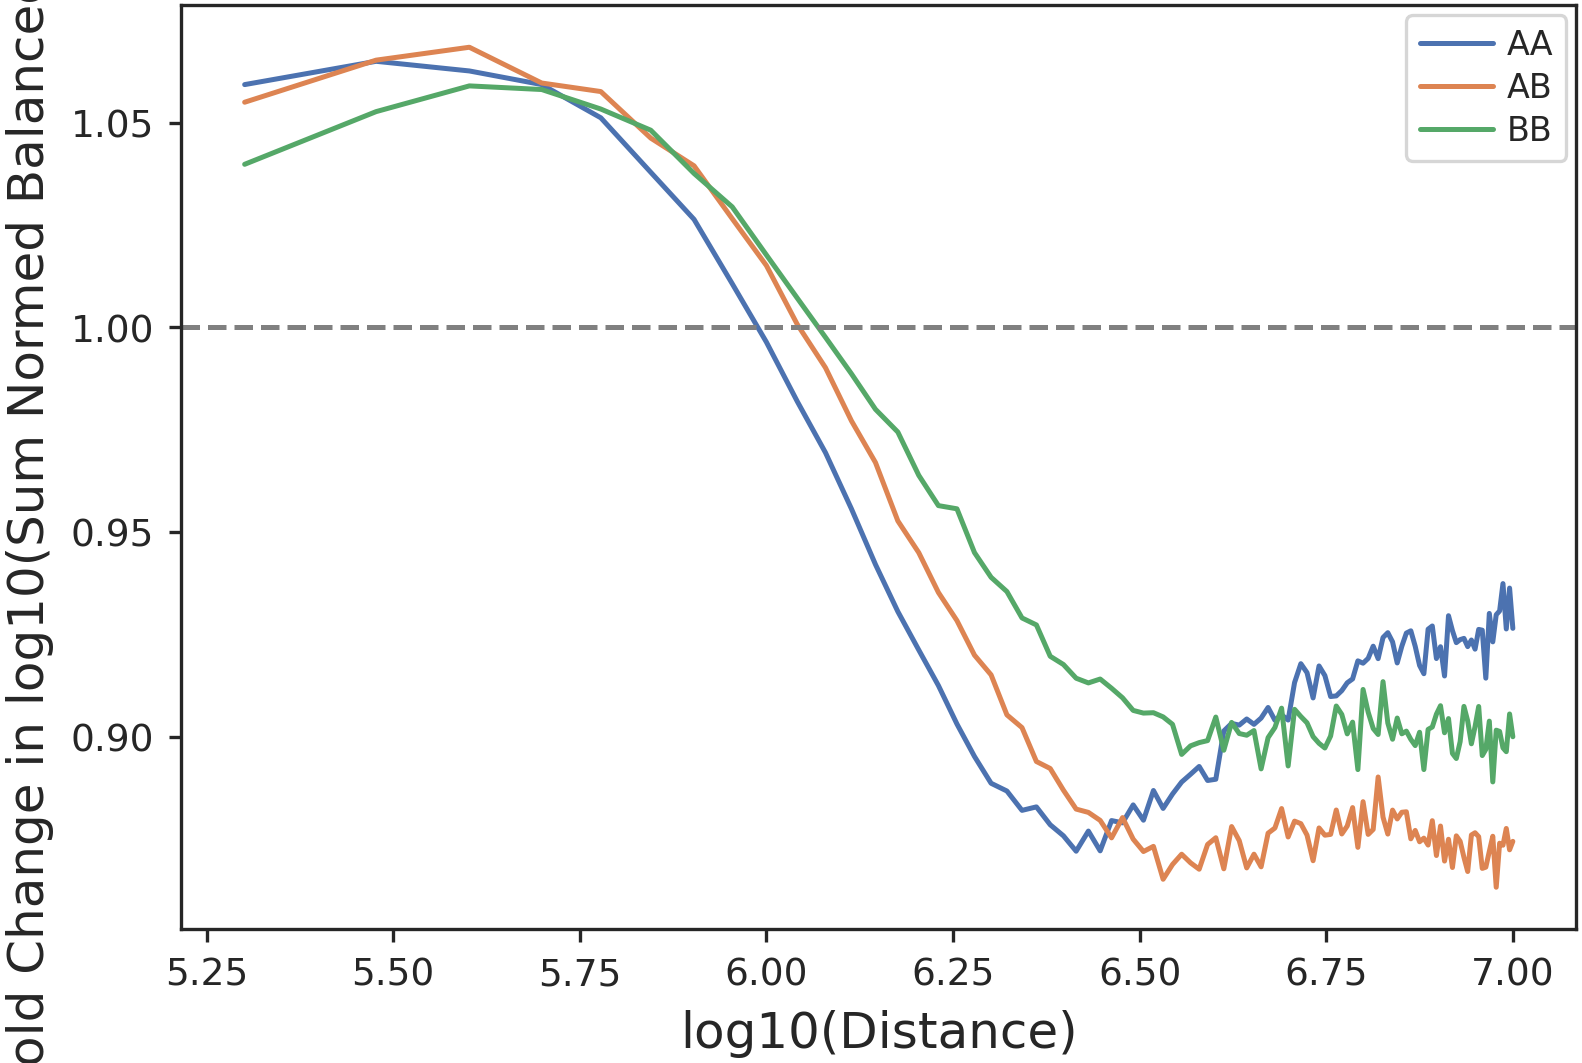

In [135]:
def sum_normed_balanced_avg(group, upper_limit=None):
    if upper_limit is not None:
        group = group[group['dist'] <= upper_limit]
    group_now = group.copy()
    total = group_now['balanced_avg'].sum()
    group_now['sum_normed_balanced_avg'] = group_now['balanced_avg'] / total if total != 0 else 0
    return group_now

upper_limit = 1e7

fig, ax = plt.subplots(figsize=(6, 4))

for compartment_pair in ['AA', 'AB', 'BB']:
    ref_df = exp_comp_ref[1][exp_comp_ref[1]['compartment_pair'] == compartment_pair].copy()
    test_df = exp_comp_test[1][exp_comp_test[1]['compartment_pair'] == compartment_pair].copy()

    ref_df = sum_normed_balanced_avg(ref_df, upper_limit=upper_limit)
    test_df = sum_normed_balanced_avg(test_df, upper_limit=upper_limit)

    y_ref = ref_df['sum_normed_balanced_avg']
    y_test = test_df['sum_normed_balanced_avg']
    x = np.log10(ref_df['dist'])

    fold_change = y_test / y_ref
    ax.plot(x, fold_change, label=compartment_pair)

# add legend, labels, and title
ax.legend()
ax.set_xlabel('log10(Distance)')
ax.set_ylabel('Fold Change in log10(Sum Normed Balanced Avg)')
# add horizontal line at y=1
ax.axhline(1, color='gray', linestyle='--')